In [1]:
!pip install -q tensorflow scikit-learn seaborn

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print(tf.__version__)

2.20.0


In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "rohanahmedsaad/custard-apple-dataset"
)

print(path)

Using Colab cache for faster access to the 'custard-apple-dataset' dataset.
/kaggle/input/custard-apple-dataset


In [4]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/custard-apple-dataset
/kaggle/input/custard-apple-dataset/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset
/kaggle/input/custard-apple-dataset/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset
/kaggle/input/custard-apple-dataset/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset/Custard Apple dataset
/kaggle/input/custard-apple-dataset/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset/Custard Apple dataset/Mealy Bug
/kaggle/input/custard-apple-dataset/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset/Custard Apple dataset/Leaf spot on Leaves
/kaggle/input/custard-apple-dataset/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset/Custard Apple dataset/Leaf spot on fruit
/kaggle/input/custard-apple-dataset/Sugar Apples  Custard Apples (Annona squamosa) Dise

In [5]:
DATASET = "/kaggle/input/custard-apple-dataset/Sugar Apples  Custard Apples (Annona squamosa) Disease Image Dataset/Custard Apple dataset/Custard Apple dataset"

In [6]:
import os

print(os.listdir(DATASET))

['Mealy Bug', 'Leaf spot on Leaves', 'Leaf spot on fruit', 'Blank Canker', 'Athracnose', 'Diplodia Rot']


In [7]:
from tensorflow.keras.utils import image_dataset_from_directory

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

CLASS_NAMES = train_ds.class_names

print(CLASS_NAMES)

Found 8226 files belonging to 6 classes.
Using 6581 files for training.
Found 8226 files belonging to 6 classes.
Using 1645 files for validation.
['Athracnose', 'Blank Canker', 'Diplodia Rot', 'Leaf spot on Leaves', 'Leaf spot on fruit', 'Mealy Bug']


In [8]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [9]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Small
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

base_model = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = layers.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = layers.Rescaling(1./255)(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    6,
    activation="softmax"
)(x)

baseline_model = Model(
    inputs,
    outputs
)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,374 (4.15 MB)

 Trainable params: 737,446 (2.81 MB)

 Non-trainable params: 350,928 (1.34 MB)

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop]
)

baseline_model.save(
    "baseline_mobilenetv3.keras"
)

Epoch 1/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 48s 163ms/step - accuracy: 0.2453 - loss: 1.7751 - val_accuracy: 0.1945 - val_loss: 1.7992
Epoch 2/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 32s 149ms/step - accuracy: 0.3130 - loss: 1.6550 - val_accuracy: 0.1945 - val_loss: 1.8017
Epoch 3/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.3322 - loss: 1.6116 - val_accuracy: 0.1945 - val_loss: 1.8148
Epoch 4/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.3667 - loss: 1.5691 - val_accuracy: 0.2128 - val_loss: 1.8271
Epoch 5/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 171ms/step - accuracy: 0.3647 - loss: 1.5591 - val_accuracy: 0.1058 - val_loss: 1.8380
Epoch 6/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.3872 - loss: 1.5333 - val_accuracy: 0.1204 - val_loss: 1.8866
Epoch 7/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 42s 151ms/step - accuracy: 0.3907 - loss: 1.5129 - val_accuracy: 0.1185 - val_loss: 2.0011
Epoch 8/30
206/206 ━━━━━━━━━━━━━━━━━━━━ 41s 151ms/step - accuracy: 0.3969 - loss: 1

In [11]:
print(max(history_baseline.history["val_accuracy"]))

0.21276596188545227


In [12]:
print(max(history_baseline.history["accuracy"]))

0.4146786332130432


In [13]:
import os

for cls in os.listdir(DATASET):
    cls_path = os.path.join(DATASET, cls)

    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))

Mealy Bug : 1604
Leaf spot on Leaves : 1255
Leaf spot on fruit : 867
Blank Canker : 1780
Athracnose : 1075
Diplodia Rot : 1645


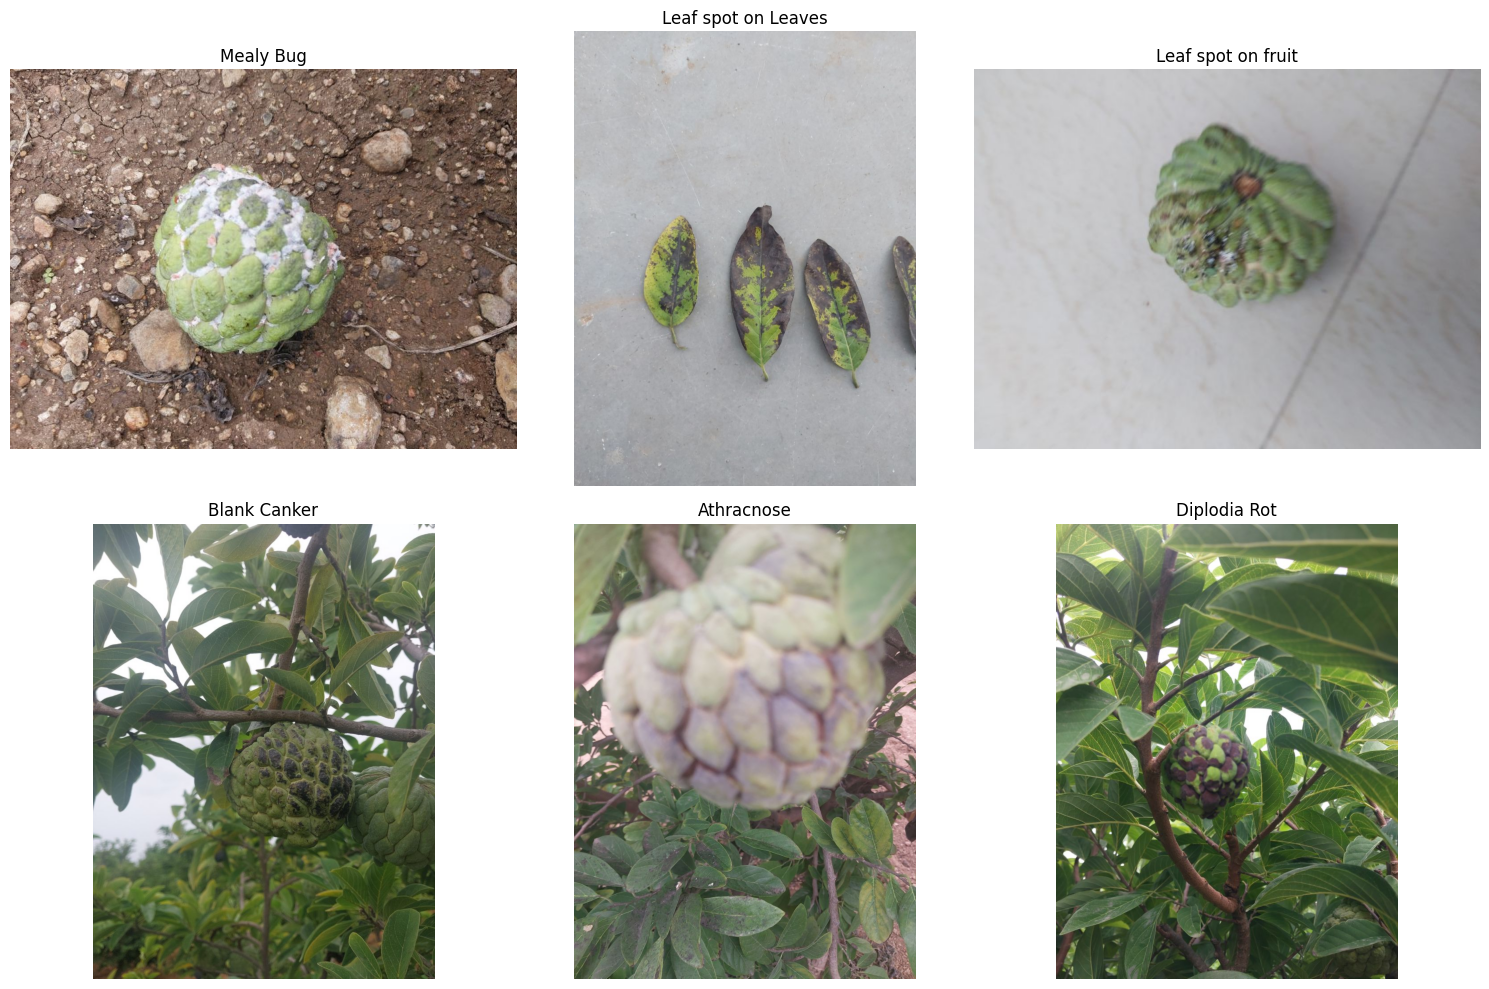

In [14]:
import matplotlib.pyplot as plt
import random
import os

classes = os.listdir(DATASET)

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes):

    img_file = random.choice(
        os.listdir(os.path.join(DATASET, cls))
    )

    img_path = os.path.join(
        DATASET,
        cls,
        img_file
    )

    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
print(CLASS_NAMES)

['Athracnose', 'Blank Canker', 'Diplodia Rot', 'Leaf spot on Leaves', 'Leaf spot on fruit', 'Mealy Bug']


In [19]:
import numpy as np

preds = baseline_model.predict(val_ds)

y_pred = np.argmax(preds, axis=1)

unique, counts = np.unique(y_pred, return_counts=True)

print("Prediction Distribution:\n")

for u, c in zip(unique, counts):
    print(CLASS_NAMES[u], ":", c)

52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step
Prediction Distribution:

Diplodia Rot : 1566
Mealy Bug : 79


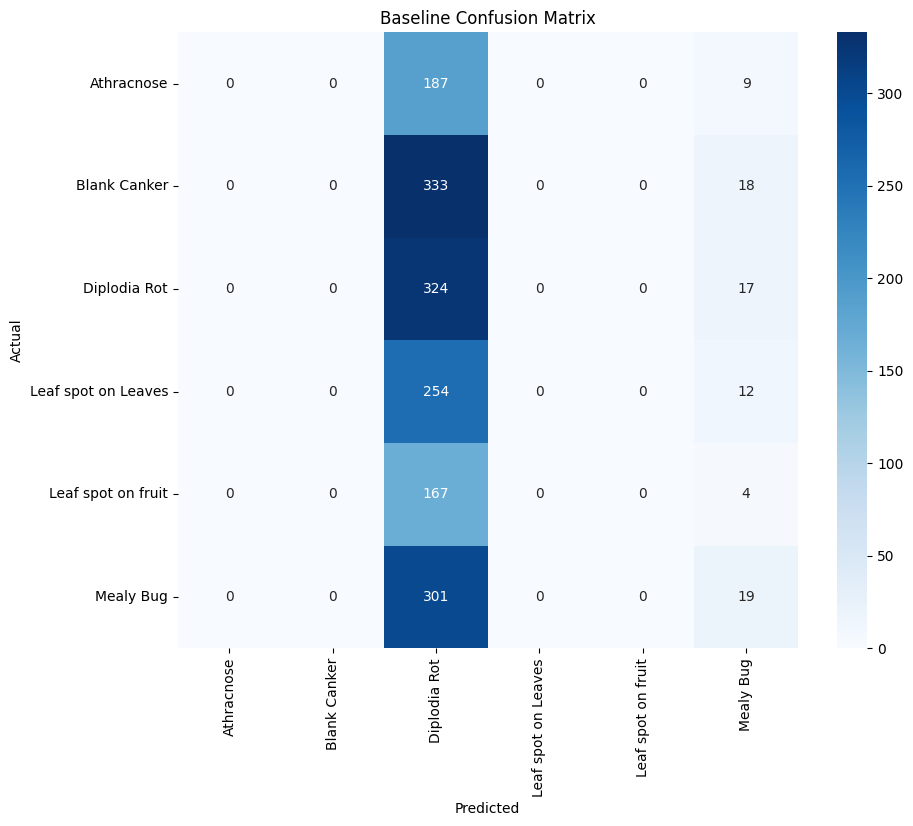

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = np.concatenate(
    [y.numpy() for x, y in val_ds],
    axis=0
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = np.concatenate(
    [y.numpy() for x, y in train_ds]
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = {
    i: weights[i]
    for i in range(len(weights))
}

print(class_weights)

{0: np.float64(1.2478194918467955), 1: np.float64(0.7675530674131094), 2: np.float64(0.8411298568507157), 3: np.float64(1.1090326929558476), 4: np.float64(1.5759099616858236), 5: np.float64(0.8542315680166147)}
